In [1]:
import torch
from torch import nn # nn contails all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

# 1. Data preparatin and loading

In [2]:
weights = 0.7
bias = 0.3

# create data

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weights * X + bias

X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

## Spliting data into training and test sets (one of the most important concept in ML in general)

In [4]:
train_split = int(0.8 * len(X))
train_split

40

In [5]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test, = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

data visualization

In [6]:
def plot_predictions(train_data = X_train , train_labels= y_train,
                     test_data = X_test, test_labels= y_test,
                     predictions= None):
  plt.figure(figsize = (10,7))

  plt.scatter(train_data, train_labels, c = "b", s=4, label="Training data")

  plt.scatter(test_data, test_labels, c = "g", s= 4, label = "Testing data")

  if predictions is not None:

    plt.scatter(test_data, predictions, c = "r", s=4, label= "Predctions")

  plt.legend(prop={"size" : 14})

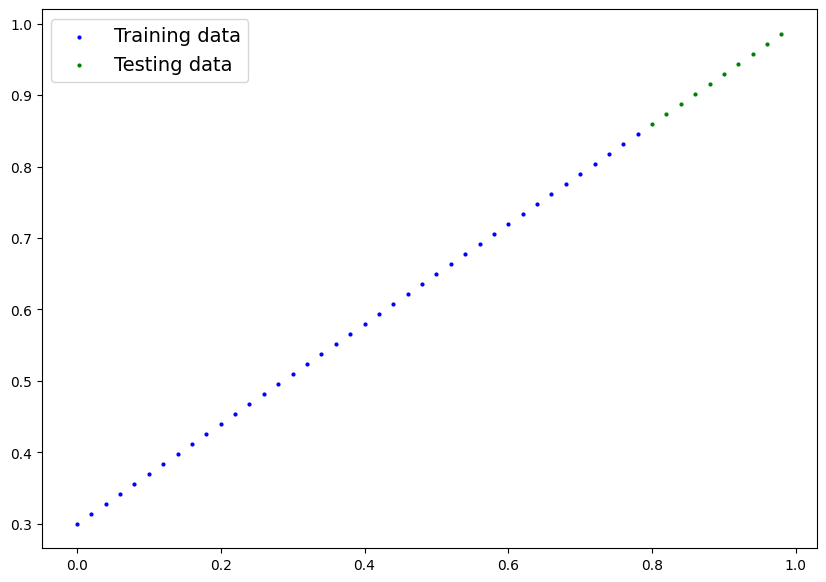

In [7]:
plot_predictions()

 #@ 2.building model

In [8]:
# create linear regression model class
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [9]:
### checking the contents of PyTorch model


# creatre random seed
torch.manual_seed(42)

#Create an instance of the model ( this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [10]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

In [11]:
weights, bias

(0.7, 0.3)

Making prediction using torch.inference_mode()


In [12]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [13]:
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.0677],
        [0.0853],
        [0.1030],
        [0.1206],
        [0.1382],
        [0.1559],
        [0.1735],
        [0.1912],
        [0.2088],
        [0.2265]])

In [14]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

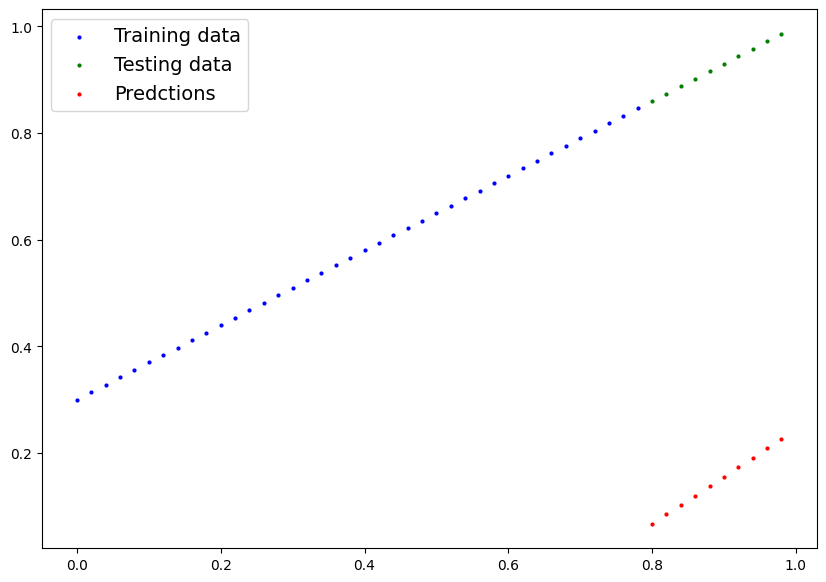

In [15]:
plot_predictions(predictions=y_preds)

to read about torch.inference_mode()

In [16]:
## 3. TRAIN MODEL

list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([-0.6382], requires_grad=True)]

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([-0.6382]))])

# setup loss function
# setup an optimizer
# building training loop

In [18]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01)

In [19]:
torch.manual_seed(42)

epochs = 300

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range (epochs):
  model_0.train() #train mode

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)
  print(f"Loss: {loss}")

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval() #trun off gradient tracking
  with torch.inference_mode():
    test_pred= model_0(X_test)

    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch:{epoch} | loss: {loss} | Test loss: {test_loss}")

  print(model_0.state_dict())


Loss: 0.8670692443847656
Epoch:0 | loss: 0.8670692443847656 | Test loss: 0.7624635696411133
OrderedDict({'weights': tensor([0.8862]), 'bias': tensor([-0.6282])})
Loss: 0.8555482625961304
OrderedDict({'weights': tensor([0.8901]), 'bias': tensor([-0.6182])})
Loss: 0.8440272212028503
OrderedDict({'weights': tensor([0.8940]), 'bias': tensor([-0.6082])})
Loss: 0.8325062990188599
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([-0.5982])})
Loss: 0.8209851384162903
OrderedDict({'weights': tensor([0.9018]), 'bias': tensor([-0.5882])})
Loss: 0.8094642758369446
OrderedDict({'weights': tensor([0.9057]), 'bias': tensor([-0.5782])})
Loss: 0.7979432940483093
OrderedDict({'weights': tensor([0.9096]), 'bias': tensor([-0.5682])})
Loss: 0.7864223122596741
OrderedDict({'weights': tensor([0.9135]), 'bias': tensor([-0.5582])})
Loss: 0.7749012112617493
OrderedDict({'weights': tensor([0.9174]), 'bias': tensor([-0.5482])})
Loss: 0.7633803486824036
OrderedDict({'weights': tensor([0.9213]), 'bias': ten

/tmp/ipykernel_466/1287121606.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, torch.tensor(loss_values).numpy(), label = "Train loss")


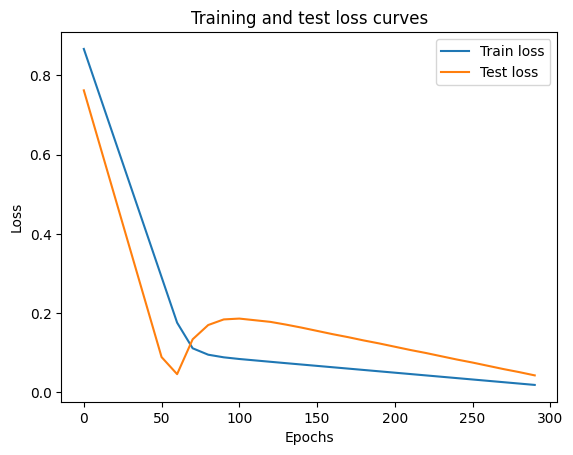

In [20]:
# plot the loss curves

plt.plot(epoch_count, torch.tensor(loss_values).numpy(), label = "Train loss")
plt.plot(epoch_count, test_loss_values, label =  "Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [24]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

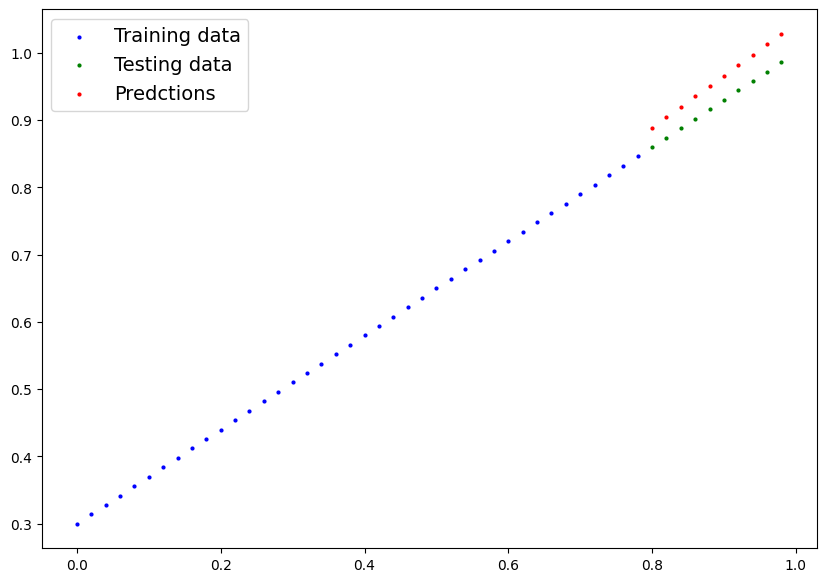

In [26]:
plot_predictions(predictions=y_preds_new)

In [23]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7755])), ('bias', tensor([0.2683]))])